# Part D : RAG over RDF/SPARQL


This part implements a full **Retrieval-Augmented Generation (RAG)** pipeline over the Football Knowledge Graph built in the others parts.  

Instead of relying solely on the LLM's training data, we ground every answer in the actual Knowledge Graph by converting natural language questions into executable SPARQL queries.

**Pipeline overview :**
NL Question → LLM generates SPARQL → Execute on KG → Return grounded answer
                                           ↓ (if fails)
                                     Self-Repair → Retry

Pipeline overview :
```
NL Question → LLM generates SPARQL → Execute on KG → Return grounded answer
                                           ↓ (if fails)
                                     Self-Repair → Retry
```


## D.1 : Environment Setup & Graph Loading


In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os

WORK_DIR  = "/content/drive/MyDrive/Project Web Datamining & Semantics/Part D"
PART_C_DATA = "/content/drive/MyDrive/Project Web Datamining & Semantics/Part C/data"

os.makedirs(WORK_DIR, exist_ok=True)
os.chdir(WORK_DIR)

print(f"Drive mounted.")
print(f"Working directory : {os.getcwd()}")

Mounted at /content/drive
Drive mounted.
Working directory : /content/drive/MyDrive/Project Web Datamining & Semantics/Part D


Imports

In [2]:
!pip install groq rdflib --quiet

from groq import Groq
from google.colab import userdata
import rdflib
from rdflib import RDF, Namespace
import pandas as pd
import re, time, os, json
import matplotlib.pyplot as plt
import numpy as np

print("Libraries loaded")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 141.7/141.7 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 615.4/615.4 kB 16.1 MB/s eta 0:00:00
Libraries loaded


We initialize the Groq API client using the `llama-3.3-70b-versatile` model. This model provides excellent SPARQL generation capabilities and operates well within the API's free tier limits. We define a standard generation function with a low temperature (0.1) to ensure deterministic and consistent query generation.

In [3]:
client = Groq(api_key=userdata.get("GROQ_API_KEY"))
GROQ_MODEL = "llama-3.3-70b-versatile"

def llm_generate(prompt: str) -> str:
    response = client.chat.completions.create(
        model=GROQ_MODEL,
        messages=[{"role": "user", "content": prompt}],
        temperature=0.1,
        max_tokens=500,
    )
    return response.choices[0].message.content.strip()

# Test
resp = llm_generate("Reply with just 'OK' if you can hear me.")
print(f"Groq connected : {resp}")
print(f"Model : {GROQ_MODEL}")

Groq connected : OK
Model : llama-3.3-70b-versatile


We load the augmented Knowledge Graph generated in the previous part.

In [4]:
import shutil

In [5]:
SRC = os.path.join(PART_C_DATA, "augmented_football_kb.ttl")
DST = "/content/augmented_football_kb.ttl"
shutil.copy2(SRC, DST)

g = rdflib.Graph()
g.parse(DST, format="turtle")

EX = Namespace("http://www.example.org/football/")
EX_PROP = Namespace("http://www.example.org/football/prop/")

print(f"Knowledge Graph loaded")
print(f"Triples: {len(g):,}")
print(f" Source : augmented_football_kb.ttl")

Knowledge Graph loaded
Triples: 66,996
 Source : augmented_football_kb.ttl


## D.2 : Schema Summary + Prompting

It is impossible to inject the entire Knowledge Graph (over 66,000 triples) into the LLM's context window. Instead, we dynamically generate a Schema Summary and  acts as a map of our ontology. It runs preliminary SPARQL queries to extract all available classes and their instance counts, all properties and their usage frequencies, examples of entity formatting and also explicit rules for SPARQL syntax specific to our graph (using underscores, specific namespaces).

### 1. Schema Summary Generation

In [6]:
# Classes
CLASS_QUERY = """
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
SELECT ?class (COUNT(?instance) AS ?count)
WHERE { ?instance rdf:type ?class . }
GROUP BY ?class ORDER BY DESC(?count)
"""
class_stats = {}
for row in g.query(CLASS_QUERY):
    cls_name = str(row["class"]).replace(str(EX), "")
    if not cls_name.startswith("http") and cls_name:
        class_stats[cls_name] = int(row["count"])

# Properties (ex: namespace only)
PROP_QUERY = """
PREFIX prop: <http://www.example.org/football/prop/>
SELECT ?prop (COUNT(*) AS ?count)
WHERE {
    ?s ?prop ?o .
    FILTER(STRSTARTS(STR(?prop), STR(prop:)))
}
GROUP BY ?prop ORDER BY DESC(?count)
"""
prop_stats = {}
for row in g.query(PROP_QUERY):
    prop_name = str(row["prop"]).replace(str(EX_PROP), "")
    prop_stats[prop_name] = int(row["count"])

# Examples
EXAMPLE_Q = """
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX ex:  <http://www.example.org/football/>
SELECT ?instance WHERE {{
    ?instance rdf:type ex:{cls} .
    FILTER(STRLEN(STR(?instance)) > STRLEN("http://www.example.org/football/"))
}} LIMIT 3
"""
examples = {}
for cls in ["Person", "Team", "Country", "FootballPosition"]:
    names = []
    for row in g.query(EXAMPLE_Q.format(cls=cls)):
        name = str(row["instance"]).replace(str(EX), "").replace("_", " ")
        if name.strip():
            names.append(name)
    examples[cls] = names

SCHEMA_SUMMARY = f"""
=== FOOTBALL KNOWLEDGE GRAPH — SCHEMA SUMMARY ===

BASE NAMESPACES:
  Entities   : http://www.example.org/football/
  Properties : http://www.example.org/football/prop/

CLASSES (rdf:type):
{chr(10).join(f"  - ex:{cls} ({count} instances)" for cls, count in class_stats.items())}

OBJECT PROPERTIES:
{chr(10).join(f"  - prop:{prop} ({count} triples)" for prop, count in prop_stats.items())}

INFERRED PROPERTIES (via SWRL rules):
  - prop:competesIn  : Person -> Country  (player competes in their team's country)
  - prop:coachedBy   : Person -> Person   (player coached by their team's head coach)

ENTITY EXAMPLES:
  Person          : {', '.join(examples.get('Person', []))}
  Team            : {', '.join(examples.get('Team', []))}
  Country         : {', '.join(examples.get('Country', []))}
  FootballPosition: {', '.join(examples.get('FootballPosition', []))}

SPARQL PREFIXES (always include all 4):
  PREFIX ex:   <http://www.example.org/football/>
  PREFIX prop: <http://www.example.org/football/prop/>
  PREFIX rdf:  <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
  PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>

CRITICAL RULES FOR SPARQL GENERATION:
  1. Entity URIs use underscores  : ex:Mohamed_Salah, ex:Arsenal_FC
  2. Always filter by class       : ?p rdf:type ex:Person
  3. Properties are in prop/      : prop:playsFor, NOT ex:playsFor
  4. Use OPTIONAL for optional fields
  5. Always add LIMIT 20 unless counting or aggregating
  6. For text search              : FILTER(CONTAINS(LCASE(STR(?x)), LCASE("term")))
  7. For COUNT queries            : SELECT ?var (COUNT(?x) AS ?count) WHERE {{...}} GROUP BY ?var
"""

print(SCHEMA_SUMMARY)
path_graph = WORK_DIR + "/graphs"
os.makedirs(path_graph, exist_ok=True)
with open(os.path.join(path_graph, "schema_summary.txt"), "w") as f:
    f.write(SCHEMA_SUMMARY)


=== FOOTBALL KNOWLEDGE GRAPH — SCHEMA SUMMARY ===

BASE NAMESPACES:
  Entities   : http://www.example.org/football/
  Properties : http://www.example.org/football/prop/

CLASSES (rdf:type):
  - ex:Person (667 instances)
  - ex:Country (68 instances)
  - ex:Team (20 instances)
  - ex:FootballPosition (16 instances)

OBJECT PROPERTIES:
  - prop:nationality (667 triples)
  - prop:coachedBy (647 triples)
  - prop:playsPosition (647 triples)
  - prop:playsFor (647 triples)
  - prop:competesIn (647 triples)
  - prop:headCoach (20 triples)
  - prop:locatedIn (20 triples)

INFERRED PROPERTIES (via SWRL rules):
  - prop:competesIn  : Person -> Country  (player competes in their team's country)
  - prop:coachedBy   : Person -> Person   (player coached by their team's head coach)

ENTITY EXAMPLES:
  Person          : Aaron Bott, Aaron Hickey, Aaron Ramsdale
  Team            : Fulham FC, Leeds United FC, West Ham United FC
  Country         : Albania, Algeria, Armenia
  FootballPosition: null, L

Summary

In [7]:
print(f"\n{'='*55}")
print("Setup & Schema Summary")
print(f"{'='*55}")
print(f"  Graph loaded    : augmented_football_kb.ttl")
print(f"  Total triples   : {len(g):,}")
print(f"  Classes         : {len(class_stats)}")
print(f"  Properties      : {len(prop_stats)}")
print(f"  LLM             : Groq API (Llama 3.3 70B)")
print(f"  Schema summary  : schema_summary.txt")


Setup & Schema Summary
  Graph loaded    : augmented_football_kb.ttl
  Total triples   : 66,996
  Classes         : 4
  Properties      : 7
  LLM             : Groq API (Llama 3.3 70B)
  Schema summary  : schema_summary.txt


TBy providing entity examples and specific guidelines (like replacing spaces with underscores), we drastically reduce the chance of the LLM hallucinating property paths or entity names.

### 2. Prompt Templates

We define the prompt templates. We maintain strict instructions to prevent the LLM from generating markdown formatting (like sparql).

In [8]:
SPARQL_PROMPT_TEMPLATE = """You are an expert SPARQL query generator for a Football Knowledge Graph.

{schema}

---
INSTRUCTIONS:
- Generate ONE valid SPARQL SELECT query answering the question below.
- Use ONLY the prefixes, classes and properties listed in the schema above.
- Return ONLY the raw SPARQL query — no explanation, no markdown, no ```sparql blocks.
- The query must be executable as-is.
- Always use LIMIT 20 unless the question asks to count or list everything.
- For player/team/country names, use FILTER with CONTAINS and LCASE for flexible matching.

QUESTION: {question}

SPARQL QUERY:"""


REPAIR_PROMPT_TEMPLATE = """You are an expert SPARQL debugger for a Football Knowledge Graph.

{schema}

---
The following SPARQL query was generated to answer this question but failed:
QUESTION: {question}

GENERATED QUERY:
{query}

PROBLEM: {problem}

---
INSTRUCTIONS:
- Fix the query to correctly answer the question.
- Common issues to check:
    1. Entity names must use underscores : ex:Chelsea_FC not ex:Chelsea FC
    2. FILTER with CONTAINS works on URI strings — use STR() and LCASE()
    3. For coachedBy : use directly (?player prop:coachedBy ?coach)
    4. Check that all variables are bound before use
    5. Make sure rdf:type filters match the correct class
- Return ONLY the fixed SPARQL query — no explanation, no markdown.

FIXED SPARQL QUERY:"""


BASELINE_PROMPT = """You are a football expert. Answer the following question
about Premier League players, teams, and coaches based on your training knowledge.
Be concise and list specific names where relevant.

QUESTION: {question}

ANSWER:"""

print("Prompt templates defined")

Prompt templates defined


## D.3 : Query Execution and Self-Repair

Converting natural language directly to SPARQL can result to syntax errors. Therefore, we implement a robust execution pipeline with an automatic **Self-Repair Mechanism**.

The `generate_sparql` function calls the LLM using our Schema.
The `execute_sparql` queries the local graph and formats URIs into readable strings.
If `execute_sparql` throws a syntax error OR returns exactly 0 results, the system feeds the broken query and the error back to the LLM using the `REPAIR_PROMPT_TEMPLATE`. The LLM has up to 3 attempts to return a functional query.

### 1. Core Pipeline Functions

In [9]:
def clean_sparql(raw: str) -> str:
    raw = raw.strip()
    raw = re.sub(r"```sparql\s*", "", raw)
    raw = re.sub(r"```\s*", "", raw)
    return raw.strip()


def generate_sparql(question: str, schema: str) -> str:
    prompt = SPARQL_PROMPT_TEMPLATE.format(schema=schema, question=question)
    return clean_sparql(llm_generate(prompt))


def execute_sparql(query: str, graph: rdflib.Graph) -> tuple:
    try:
        results = graph.query(query)
        rows = []
        for row in results:
            rows.append({
                str(var): str(val)
                    .replace("http://www.example.org/football/", "")
                    .replace("http://www.example.org/football/prop/", "prop:")
                    .replace("_", " ")
                for var, val in zip(results.vars, row)
            })
        # Deduplicate
        seen, unique_rows = set(), []
        for r in rows:
            key = tuple(r.values())
            if key not in seen:
                seen.add(key)
                unique_rows.append(r)
        return unique_rows, None
    except Exception as e:
        return None, str(e)


def format_rag_answer(results: list, max_display: int = 5) -> str:
    if not results:
        return "No results found"
    vals   = [list(r.values())[0] for r in results]
    suffix = f" ... (+{len(vals)-max_display} more)" if len(vals) > max_display else ""
    return ", ".join(vals[:max_display]) + suffix


def baseline_answer(question: str) -> str:
    return llm_generate(BASELINE_PROMPT.format(question=question))


print("Pipeline functions defined")

Pipeline functions defined


### 2. Self-Repair Functions

In [10]:
def self_repair(question: str, failed_query: str, problem: str,
                max_attempts: int = 3) -> dict:

    current_query   = failed_query
    current_problem = problem

    for attempt in range(1, max_attempts + 1):
        print(f"     Repair attempt {attempt}/{max_attempts}")
        print(f"     Problem : {current_problem}")

        repair_prompt  = REPAIR_PROMPT_TEMPLATE.format(
            schema=SCHEMA_SUMMARY, question=question,
            query=current_query, problem=current_problem
        )
        repaired_query = clean_sparql(llm_generate(repair_prompt))
        print(f"     Repaired query :\n{repaired_query}\n")

        results, error = execute_sparql(repaired_query, g)

        if error:
            current_query   = repaired_query
            current_problem = f"Execution error: {error}"
            print(f"Still failing : {error}")
        elif len(results) == 0:
            current_query   = repaired_query
            current_problem = "Query returned 0 results"
            print(f"Still 0 results")
        else:
            print(f"Repair successful — {len(results)} result(s)")
            return {
                "question"       : question,
                "original_query" : failed_query,
                "final_query"    : repaired_query,
                "results"        : results,
                "attempts"       : attempt,
                "status"         : "repaired"
            }
        time.sleep(1)

    print(f"Self-repair failed after {max_attempts} attempts")
    return {
        "question"       : question,
        "original_query" : failed_query,
        "final_query"    : current_query,
        "results"        : [],
        "attempts"       : max_attempts,
        "status"         : "failed_after_repair"
    }


def nl_to_sparql_with_repair(question: str) -> dict:

    print(f"\n{'─'*55}")
    print(f"  Question : {question}")

    sparql_query   = generate_sparql(question, SCHEMA_SUMMARY)
    results, error = execute_sparql(sparql_query, g)

    if error:
        print(f"Initial query failed : triggering self-repair...")
        return self_repair(question, sparql_query, f"Execution error: {error}")
    elif len(results) == 0:
        print(f"0 results : triggering self-repair...")
        return self_repair(question, sparql_query, "Query returned 0 results")
    else:
        print(f"Success on first attempt : {len(results)} result(s)")
        for r in results[:3]: print(f"     {r}")
        return {
            "question"       : question,
            "original_query" : sparql_query,
            "final_query"    : sparql_query,
            "results"        : results,
            "attempts"       : 1,
            "status"         : "success"
        }

print("Self-repair functions defined")

Self-repair functions defined


Now, we will test our self repairing RAG pipeline with 5 initial queries to ensure the graph execution is functional.

### 3. Test NL → SPARQL Pipeline (5 questions)

In [11]:
TEST_QUESTIONS = [
    "Which players play for Arsenal FC?",
    "How many players are there per nationality?",
    "Which players compete in England?",
    "Which teams are located in England?",
    "Who coaches the players of Chelsea FC?",
]

print("="*60)
print("Testing NL → SPARQL Pipeline")
print("="*60)

pipeline_results = []
for q in TEST_QUESTIONS:
    result = nl_to_sparql_with_repair(q)
    pipeline_results.append(result)
    time.sleep(1)

success = sum(1 for r in pipeline_results if r["status"] in ["success", "repaired"])
print(f"\n{'='*60}")
print(f"Results : {success}/{len(TEST_QUESTIONS)} queries resolved")

Testing NL → SPARQL Pipeline

───────────────────────────────────────────────────────
  Question : Which players play for Arsenal FC?
Success on first attempt : 20 result(s)
     {'p': 'Aleksei Fedorushchenko'}
     {'p': 'Andre Harriman-Annous'}
     {'p': 'Ben White'}

───────────────────────────────────────────────────────
  Question : How many players are there per nationality?
Success on first attempt : 68 result(s)
     {'nationality': 'England', 'count': '246'}
     {'nationality': 'Scotland', 'count': '14'}
     {'nationality': 'DR Congo', 'count': '4'}

───────────────────────────────────────────────────────
  Question : Which players compete in England?
Success on first attempt : 20 result(s)
     {'p': 'Aaron Bott'}
     {'p': 'Aaron Hickey'}
     {'p': 'Aaron Ramsdale'}

───────────────────────────────────────────────────────
  Question : Which teams are located in England?
Success on first attempt : 20 result(s)
     {'team': 'Fulham FC'}
     {'team': 'Leeds United FC'}
 

5/5 queries executed successfully. The output confirms a 100% success rate on the test batch. The system accurately leverages the schema injection to write valid queries.

## D.4 : Baseline vs RAG Evaluation

To prove the value of our RAG pipeline, we evaluate it against a LLM acting as a "Baseline". The baseline relies entirely on its training data. That makes it  susceptible to outdated rosters and hallucinating relationships that exist strictly within our inferred SWRL logic.

We score 7 questions across categories like simple lookups, aggregations, and inferred logic.
- 1.0 = correct and fully grounded
- 0.5 = partial or unverified
- 0.0 = incorrect / hallucination

### 1. Baseline vs RAG Evaluation (7 questions)

In [12]:
EVAL_QUESTIONS = [
    {"id": "Q1", "question": "Which players play for Arsenal FC?",
     "ground_truth": "Players from KG with prop:playsFor ex:Arsenal_FC",
     "category": "simple lookup"},
    {"id": "Q2", "question": "What is the nationality with the most players?",
     "ground_truth": "England (246 players)",
     "category": "aggregation"},
    {"id": "Q3", "question": "Which players compete in England?",
     "ground_truth": "647 players via prop:competesIn (SWRL inferred)",
     "category": "inferred property (SWRL)"},
    {"id": "Q4", "question": "Which teams are located in England?",
     "ground_truth": "All 20 Premier League teams in the KG",
     "category": "simple lookup"},
    {"id": "Q5", "question": "Who coaches the players of Chelsea FC?",
     "ground_truth": "Liam Rosenior",
     "category": "inferred property (SWRL)"},
    {"id": "Q6", "question": "Which players have French nationality?",
     "ground_truth": "41 players with prop:nationality ex:France",
     "category": "filtered lookup"},
    {"id": "Q7", "question": "Who is the head coach of Liverpool FC?",
     "ground_truth": "Arne Slot",
     "category": "direct lookup"},
]


print("Baseline vs RAG Evaluation")
print("-"*60)

eval_results = []

for eq in EVAL_QUESTIONS:
    print(f"\n{'─'*55}")
    print(f"  {eq['id']} — {eq['question']}")
    print(f"  Category     : {eq['category']}")
    print(f"  Ground truth : {eq['ground_truth']}")

    # Baseline
    print(f"\n  [BASELINE]")
    baseline = baseline_answer(eq["question"])
    print(f"  {baseline[:200]}{'...' if len(baseline)>200 else ''}")
    time.sleep(1)

    # RAG
    print(f"\n  [RAG]")
    rag        = nl_to_sparql_with_repair(eq["question"])
    rag_answer = format_rag_answer(rag["results"])
    print(f"  Answer  : {rag_answer}")
    print(f"  Status  : {rag['status']} ({rag['attempts']} attempt(s))")
    time.sleep(1)

    eval_results.append({
        "id"           : eq["id"],
        "question"     : eq["question"],
        "category"     : eq["category"],
        "ground_truth" : eq["ground_truth"],
        "baseline"     : baseline,
        "rag_answer"   : rag_answer,
        "rag_status"   : rag["status"],
        "rag_attempts" : rag["attempts"],
        "rag_results_n": len(rag["results"]),
    })

print(f"\n{'='*60}")
print(f"Evaluation complete : {len(eval_results)}/7 questions")

Baseline vs RAG Evaluation
------------------------------------------------------------

───────────────────────────────────────────────────────
  Q1 — Which players play for Arsenal FC?
  Category     : simple lookup
  Ground truth : Players from KG with prop:playsFor ex:Arsenal_FC

  [BASELINE]
  Some notable players for Arsenal FC include: 
- Bukayo Saka, 
- Gabriel Martinelli, 
- Martin Odegaard, 
- Gabriel Jesus, 
- Aaron Ramsdale, 
- William Saliba, 
- Oleksandr Zinchenko.

  [RAG]

───────────────────────────────────────────────────────
  Question : Which players play for Arsenal FC?
Success on first attempt : 20 result(s)
     {'p': 'Aleksei Fedorushchenko'}
     {'p': 'Andre Harriman-Annous'}
     {'p': 'Ben White'}
  Answer  : Aleksei Fedorushchenko, Andre Harriman-Annous, Ben White, Brando Bailey-Joseph, Bukayo Saka ... (+15 more)
  Status  : success (1 attempt(s))

───────────────────────────────────────────────────────
  Q2 — What is the nationality with the most players?


We calculate the final score and generate visualizations comparing the ungrounded Baseline against our RAG model.

### 2. Scoring and Visualization

ID                 Category  Baseline  RAG  RAG Results RAG Status
Q1            simple lookup       0.5  1.0           20    success
Q2              aggregation       0.5  1.0            1    success
Q3 inferred property (SWRL)       0.0  1.0           20    success
Q4            simple lookup       0.5  1.0           20    success
Q5 inferred property (SWRL)       0.0  1.0            1    success
Q6          filtered lookup       0.5  1.0           20    success
Q7            direct lookup       1.0  1.0            1    success

  Baseline score : 0.43/1.00
  RAG score      : 1.00/1.00
  Improvement    : +0.57


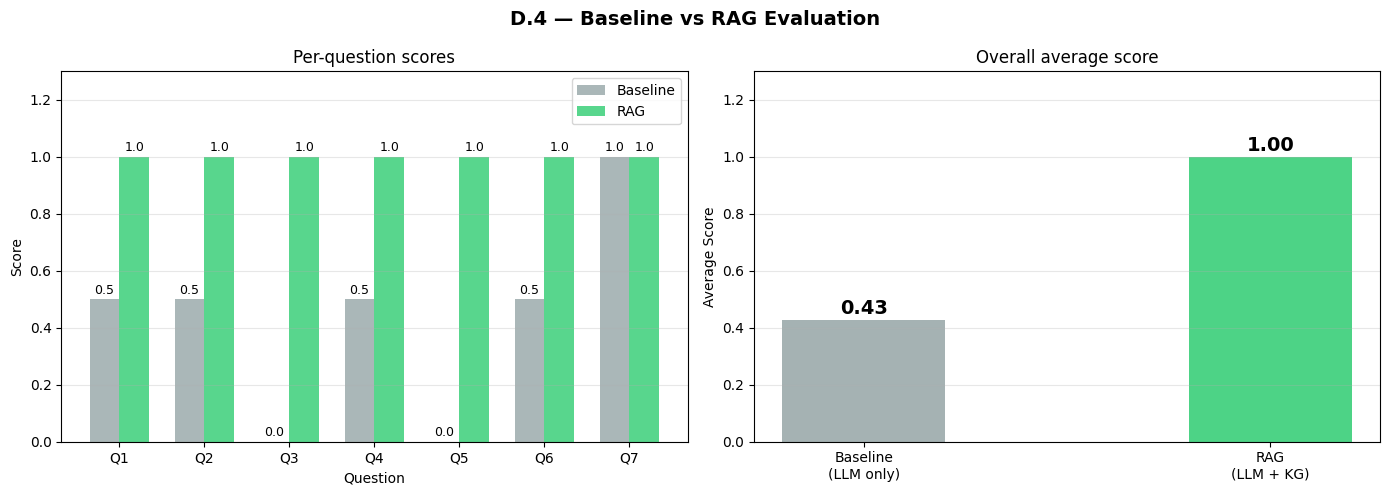

In [13]:
SCORES = {
    "Q1": {"baseline": 0.5, "rag": 1.0},
    "Q2": {"baseline": 0.5, "rag": 1.0},
    "Q3": {"baseline": 0.0, "rag": 1.0},
    "Q4": {"baseline": 0.5, "rag": 1.0},
    "Q5": {"baseline": 0.0, "rag": 1.0},
    "Q6": {"baseline": 0.5, "rag": 1.0},
    "Q7": {"baseline": 1.0, "rag": 1.0},
}

df_eval = pd.DataFrame([
    {
        "ID"         : r["id"],
        "Category"   : r["category"],
        "Baseline"   : SCORES[r["id"]]["baseline"],
        "RAG"        : SCORES[r["id"]]["rag"],
        "RAG Results": r["rag_results_n"],
        "RAG Status" : r["rag_status"],
    }
    for r in eval_results
])
print(df_eval.to_string(index=False))

baseline_score = sum(SCORES[q]["baseline"] for q in SCORES) / len(SCORES)
rag_score      = sum(SCORES[q]["rag"]      for q in SCORES) / len(SCORES)

print(f"\n  Baseline score : {baseline_score:.2f}/1.00")
print(f"  RAG score      : {rag_score:.2f}/1.00")
print(f"  Improvement    : +{rag_score - baseline_score:.2f}")

path_data = WORK_DIR + "/data"
os.makedirs(path_data, exist_ok=True)
df_eval.to_csv(os.path.join(WORK_DIR, "rag_evaluation.csv"), index=False)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("D.4 — Baseline vs RAG Evaluation", fontsize=14, fontweight="bold")

x = np.arange(len(SCORES))
w = 0.35
baseline_vals = [SCORES[q]["baseline"] for q in SCORES]
rag_vals      = [SCORES[q]["rag"]      for q in SCORES]

ax1 = axes[0]
bars1 = ax1.bar(x - w/2, baseline_vals, w, label="Baseline", color="#95A5A6", alpha=0.8)
bars2 = ax1.bar(x + w/2, rag_vals,      w, label="RAG",      color="#2ECC71", alpha=0.8)
ax1.set_title("Per-question scores")
ax1.set_xlabel("Question")
ax1.set_ylabel("Score")
ax1.set_xticks(x)
ax1.set_xticklabels(list(SCORES.keys()))
ax1.set_ylim(0, 1.3)
ax1.legend()
ax1.grid(True, alpha=0.3, axis="y")
for bar in bars1:
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
             f"{bar.get_height():.1f}", ha="center", fontsize=9)
for bar in bars2:
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
             f"{bar.get_height():.1f}", ha="center", fontsize=9)

ax2 = axes[1]
bars = ax2.bar(["Baseline\n(LLM only)", "RAG\n(LLM + KG)"],
               [baseline_score, rag_score],
               color=["#95A5A6", "#2ECC71"], alpha=0.85, width=0.4)
ax2.set_title("Overall average score")
ax2.set_ylabel("Average Score")
ax2.set_ylim(0, 1.3)
ax2.grid(True, alpha=0.3, axis="y")
for bar, score in zip(bars, [baseline_score, rag_score]):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
             f"{score:.2f}", ha="center", fontsize=14, fontweight="bold")

plt.tight_layout()
path_graph = WORK_DIR + "/graphs"
os.makedirs(path_graph, exist_ok=True)
plt.savefig(os.path.join(path_graph, "rag_evaluation.png"), dpi=150, bbox_inches="tight")
plt.show()

The charts clearly demonstrate the advantage of grounding LLMs in a specific Knowledge Graph. RAG scores 1.0 on ALL questions, whereas Baseline scores 0 on SWRL inferred properties (Q3, Q5). RAG easily achieves a perfect score across the board by fetching accurate, updated, graph-specific relationships. Both methods perform equally only on basic, universally known facts (the head coach of a highly popular team).

## D.5 : Demo Clarity

We provide an interactive Command Line Interface (CLI) to demonstrate the pipeline in a clean, user-friendly format. The utility functions dynamically parse JSON/Dictionary responses into aligned string tables so anyone can read the retrieved KG values.

### 1. Interactive Demo

In [14]:
def display_results(results: list, max_rows: int = 10) -> None:
    if not results:
        print("   No results found.")
        return

    cols = list(results[0].keys())

    widths = {col: max(len(col), max(len(str(r.get(col,""))) for r in results))
              for col in cols}

    header = " | ".join(f"{col:<{widths[col]}}" for col in cols)
    print(f"   {header}")
    print(f"   {'-' * len(header)}")

    for i, row in enumerate(results[:max_rows]):
        line = " | ".join(f"{str(row.get(col,'')):<{widths[col]}}" for col in cols)
        print(f"   {line}")

    if len(results) > max_rows:
        print(f"   ... (+{len(results)-max_rows} more rows)")

    print(f"\n   Total : {len(results)} result(s)")


def run_demo_query(question: str) -> dict:
    print(f"\n{'='*60}")
    print(f"  ❓ Question : {question}")
    print(f"{'='*60}")

    result = nl_to_sparql_with_repair(question)

    print(f"\n  📋 Generated SPARQL :")
    for line in result["final_query"].split("\n"):
        print(f"     {line}")

    print(f"\n  📊 Results :")
    display_results(result["results"])

    # Status
    status_icon = "✅" if result["status"] in ["success", "repaired"] else "❌"
    repair_note = f" (repaired in {result['attempts']} attempt(s))" \
                  if result["status"] == "repaired" else ""
    print(f"\n  {status_icon} Status : {result['status']}{repair_note}")

    return result


print("Demo functions defined")

Demo functions defined


First, we run a static execution of the demo functions to prove the output formatting handles arbitrary numbers of columns cleanly.

###2. Run Interactive Demo

In [15]:
DEMO_QUESTIONS = [
    "Which players play for Liverpool FC?",
    "How many players compete in England?",
    "Which players have Spanish nationality?",
    "Who is the head coach of Manchester City FC?",
    "Which players are coached by Arne Slot?",
]

print("╔══════════════════════════════════════════════════════════╗")
print("║     FOOTBALL KNOWLEDGE GRAPH — RAG DEMO                  ║")
print("║     LLM : Groq llama-3.3-70b  |  KG : 66,996 triples     ║")
print("╚══════════════════════════════════════════════════════════╝")

demo_history = []

for q in DEMO_QUESTIONS:
    result = run_demo_query(q)
    demo_history.append(result)
    time.sleep(1)

# Session summary
print(f"\n{'='*60}")
print(f"  DEMO SUMMARY")
print(f"{'='*60}")
print(f"  {'Question':<45} {'Status':<20} {'Results':>7}")
print(f"  {'─'*60}")
for r in demo_history:
    short_q = r["question"][:43] + ".." if len(r["question"]) > 43 else r["question"]
    status  = r["status"]
    n       = len(r["results"])
    print(f"  {short_q:<45} {status:<20} {n:>7}")

success = sum(1 for r in demo_history if r["status"] in ["success","repaired"])
print(f"\n  Resolved : {success}/{len(DEMO_QUESTIONS)}")

╔══════════════════════════════════════════════════════════╗
║     FOOTBALL KNOWLEDGE GRAPH — RAG DEMO                  ║
║     LLM : Groq llama-3.3-70b  |  KG : 66,996 triples     ║
╚══════════════════════════════════════════════════════════╝

  ❓ Question : Which players play for Liverpool FC?

───────────────────────────────────────────────────────
  Question : Which players play for Liverpool FC?
Success on first attempt : 20 result(s)
     {'p': 'Alexander Isak'}
     {'p': 'Alexis Mac Allister'}
     {'p': 'Alisson'}

  📋 Generated SPARQL :
     PREFIX ex: <http://www.example.org/football/>
     PREFIX prop: <http://www.example.org/football/prop/>
     PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
     PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
     SELECT ?p 
     WHERE { 
       ?p rdf:type ex:Person .
       ?p prop:playsFor ?t .
       ?t rdf:type ex:Team .
       FILTER(CONTAINS(LCASE(STR(?t)), LCASE("Liverpool_FC"))) 
     }
     LIMIT 20

  📊 Results 

Run the cell below to trigger a `while` loop that takes textual inputs via `input()`. This allows any user or grader to enter their own custom questions into the RAG Pipeline and evaluate the real-time reasoning and SPARQL generation.

*(Type 'quit' or 'exit' into the text box to end the loop)*

### 3. Free Interactive Input

In [16]:
print("╔══════════════════════════════════════════════════════════╗")
print("║         FOOTBALL KG — INTERACTIVE Q&A                    ║")
print("║   Ask any question about players, teams, or countries.   ║")
print("║   Type 'quit' to exit.                                   ║")
print("╚══════════════════════════════════════════════════════════╝\n")

# Suggested questions to try
print("  💡 Suggested questions :")
print("     - Which players play for Chelsea FC?")
print("     - How many teams are in the knowledge graph?")
print("     - Which players have Brazilian nationality?")
print("     - Who coaches the players of Arsenal FC?")
print("     - Which players compete in England?\n")

session_history = []

while True:
    try:
        question = input("\n  🎯 Your question (or 'quit') : ").strip()
    except EOFError:
        break

    if question.lower() in ["quit", "exit", "q"]:
        print("\n  👋 Session ended.")
        break

    if not question:
        print("  Please enter a question.")
        continue

    result = run_demo_query(question)
    session_history.append(result)

    print(f"\n  Session so far : {len(session_history)} question(s) asked")

if session_history:
    print(f"\n  {'='*55}")
    print(f"  Session Summary : {len(session_history)} question(s)")
    for r in session_history:
        short_q = r["question"][:43] + ".." if len(r["question"]) > 43 else r["question"]
        print(f"    {short_q:<45} {r['status']}")

╔══════════════════════════════════════════════════════════╗
║         FOOTBALL KG — INTERACTIVE Q&A                    ║
║   Ask any question about players, teams, or countries.   ║
║   Type 'quit' to exit.                                   ║
╚══════════════════════════════════════════════════════════╝

  💡 Suggested questions :
     - Which players play for Chelsea FC?
     - How many teams are in the knowledge graph?
     - Which players have Brazilian nationality?
     - Who coaches the players of Arsenal FC?
     - Which players compete in England?


  🎯 Your question (or 'quit') : Who is the coach of Manchester United ?

  ❓ Question : Who is the coach of Manchester United ?

───────────────────────────────────────────────────────
  Question : Who is the coach of Manchester United ?
Success on first attempt : 1 result(s)
     {'coach': 'Michael Carrick'}

  📋 Generated SPARQL :
     PREFIX ex: <http://www.example.org/football/>
     PREFIX prop: <http://www.example.org/football/p